In [1]:
# ── Notebook 04 — EDA ───────────────────────────────────────────────────────
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

REPO_ROOT   = Path().resolve().parents[1]
CLEAN_DIR   = REPO_ROOT / "Data" / "Clean"
REPORTS_DIR = REPO_ROOT / "Reports" / "EDA-Fantasy"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

with open(CLEAN_DIR / "merged_non_western_fantasy.json") as f:
    df = pd.DataFrame(json.load(f))
print(f"Loaded: {len(df):,} books")

# Style
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print(f"── Dataset Overview ──")
print(f"  Total books:       {len(df):,}")
print(f"  Unique authors:    {df['author'].nunique():,}")
print(f"  Sources:           {df['source'].value_counts().to_dict()}")
print(f"  Year range:        {df['year_published'].min()} – {df['year_published'].max()}")
print(f"  Avg rating range:  {df['avg_rating'].min()} – {df['avg_rating'].max()}")
print(f"\n── Source tag breakdown ──")
print(df["source_tag"].value_counts().to_string())

Loaded: 3,995 books
── Dataset Overview ──
  Total books:       3,995
  Unique authors:    2,786
  Sources:           {'goodreads': 2086, 'open_library': 1909}
  Year range:        1465.0 – 2027.0
  Avg rating range:  0.0 – 5.0

── Source tag breakdown ──
source_tag
asian-fantasy              965
afrofuturism               772
africa                     370
japanese                   361
chinese                    342
south_asian                327
african-fantasy            216
middle_eastern             162
latin_american             133
middle-eastern-fantasy      54
australian-fantasy          41
wuxia                       36
indigenous-fantasy          31
korean                      31
southeast_asian             23
asian-science-fiction       21
xianxia                     18
filipino                    18
indigenous_americas         18
latin-american-fantasy      16
oceania                     12
anansi                      10
south-american-fantasy       8
orisha              

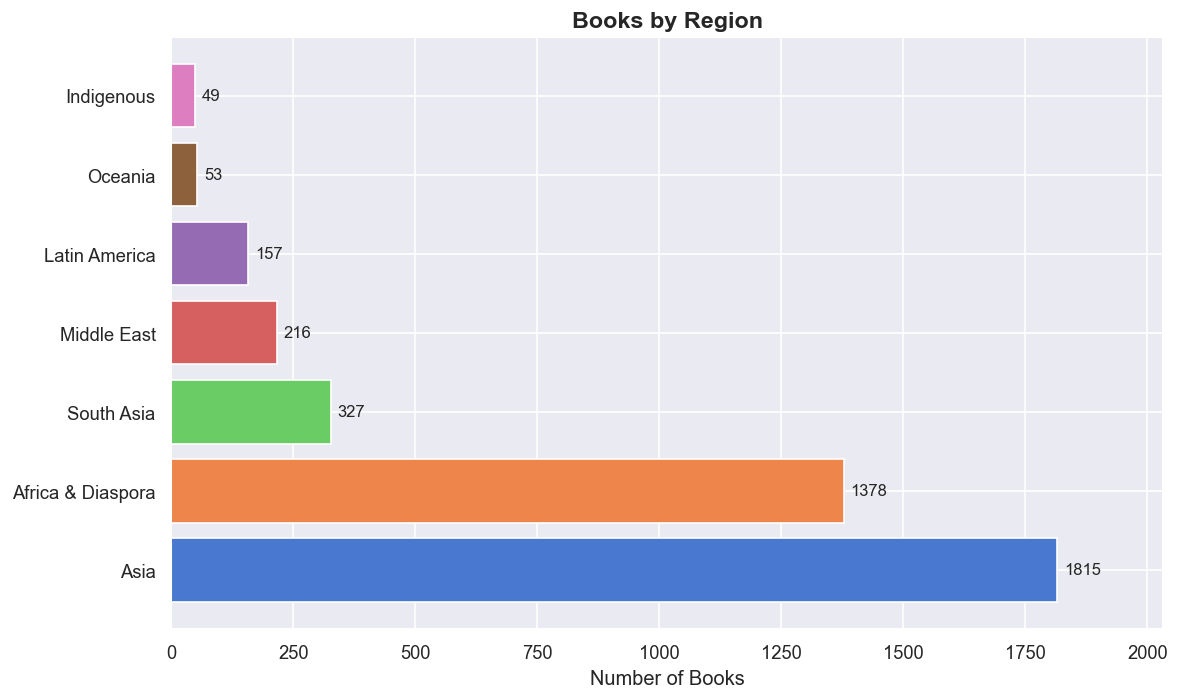

✅ Chart 1 saved


In [2]:
# ── Chart 1 — Books by region ───────────────────────────────────────────────

# Consolidate source_tags into clean regions
REGION_MAP = {
    "asian-fantasy":           "Asia",
    "japanese":                "Asia",
    "chinese":                 "Asia",
    "korean":                  "Asia",
    "wuxia":                   "Asia",
    "xianxia":                 "Asia",
    "southeast_asian":         "Asia",
    "filipino":                "Asia",
    "asian-science-fiction":   "Asia",
    "afrofuturism":            "Africa & Diaspora",
    "africa":                  "Africa & Diaspora",
    "african-fantasy":         "Africa & Diaspora",
    "african-science-fiction": "Africa & Diaspora",
    "afrofuturism":            "Africa & Diaspora",
    "anansi":                  "Africa & Diaspora",
    "orisha":                  "Africa & Diaspora",
    "igbo":                    "Africa & Diaspora",
    "zulu":                    "Africa & Diaspora",
    "akan":                    "Africa & Diaspora",
    "yoruba":                  "Africa & Diaspora",
    "south_asian":             "South Asia",
    "middle_eastern":          "Middle East",
    "middle-eastern-fantasy":  "Middle East",
    "latin_american":          "Latin America",
    "latin-american-fantasy":  "Latin America",
    "south-american-fantasy":  "Latin America",
    "indigenous_americas":     "Indigenous",
    "indigenous-fantasy":      "Indigenous",
    "oceania":                 "Oceania",
    "australian-fantasy":      "Oceania",
}

df["region"] = df["source_tag"].map(REGION_MAP).fillna("Other")

region_counts = df["region"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(region_counts.index, region_counts.values, color=sns.color_palette("muted", len(region_counts)))
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel("Number of Books")
ax.set_title("Books by Region", fontsize=14, fontweight="bold")
ax.set_xlim(0, region_counts.max() * 1.12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "01_books_by_region.png")
plt.show()
print("✅ Chart 1 saved")

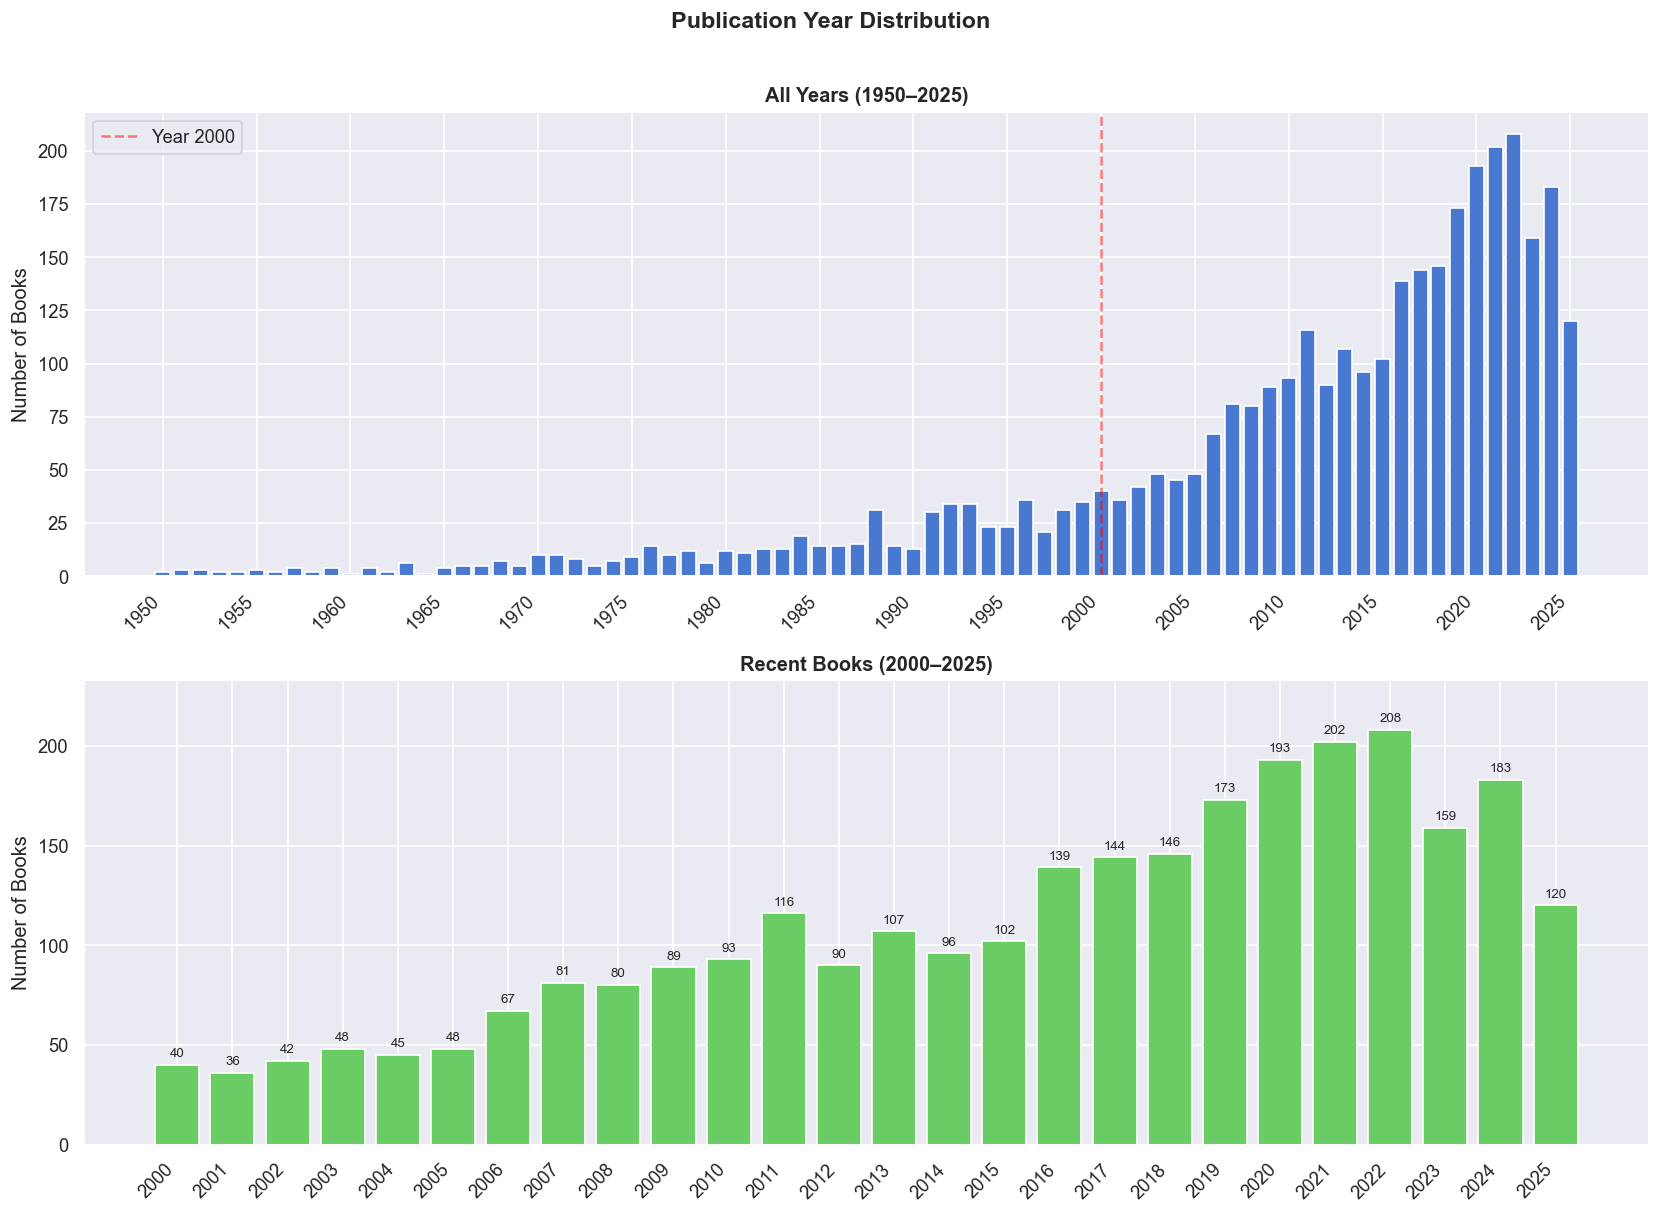

✅ Chart 2 saved


In [3]:
# ── Chart 2 — Fixed: no .0, both time periods ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ── Panel 1: 1950–2025 ─────────────────────────────────────────────────────
year_all = df[(df["year_published"] >= 1950) & (df["year_published"] <= 2025)]
counts_all = year_all["year_published"].value_counts().sort_index()

ax1.bar(counts_all.index, counts_all.values,
        color=sns.color_palette("muted")[0], edgecolor="white", width=0.8)
ax1.axvline(x=2000, color="red", linestyle="--", alpha=0.5, label="Year 2000")
ax1.set_xticks(range(1950, 2026, 5))
ax1.set_xticklabels(range(1950, 2026, 5), rotation=45, ha="right")
ax1.set_ylabel("Number of Books")
ax1.set_title("All Years (1950–2025)", fontsize=12, fontweight="bold")
ax1.legend()

# ── Panel 2: 2000–2025 zoomed with labels ──────────────────────────────────
year_recent = df[(df["year_published"] >= 2000) & (df["year_published"] <= 2025)]
counts_recent = year_recent["year_published"].value_counts().sort_index()

# Fix the .0 — convert to int for display
counts_recent.index = counts_recent.index.astype(int)

bars = ax2.bar(counts_recent.index, counts_recent.values,
               color=sns.color_palette("muted")[2], edgecolor="white", width=0.8)
ax2.bar_label(bars, padding=3, fontsize=8)
ax2.set_xticks(counts_recent.index)
ax2.set_xticklabels(counts_recent.index.astype(int), rotation=45, ha="right")
ax2.set_ylabel("Number of Books")
ax2.set_title("Recent Books (2000–2025)", fontsize=12, fontweight="bold")
ax2.set_ylim(0, counts_recent.max() * 1.12)

fig.suptitle("Publication Year Distribution", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "02_publication_years.png", bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved")

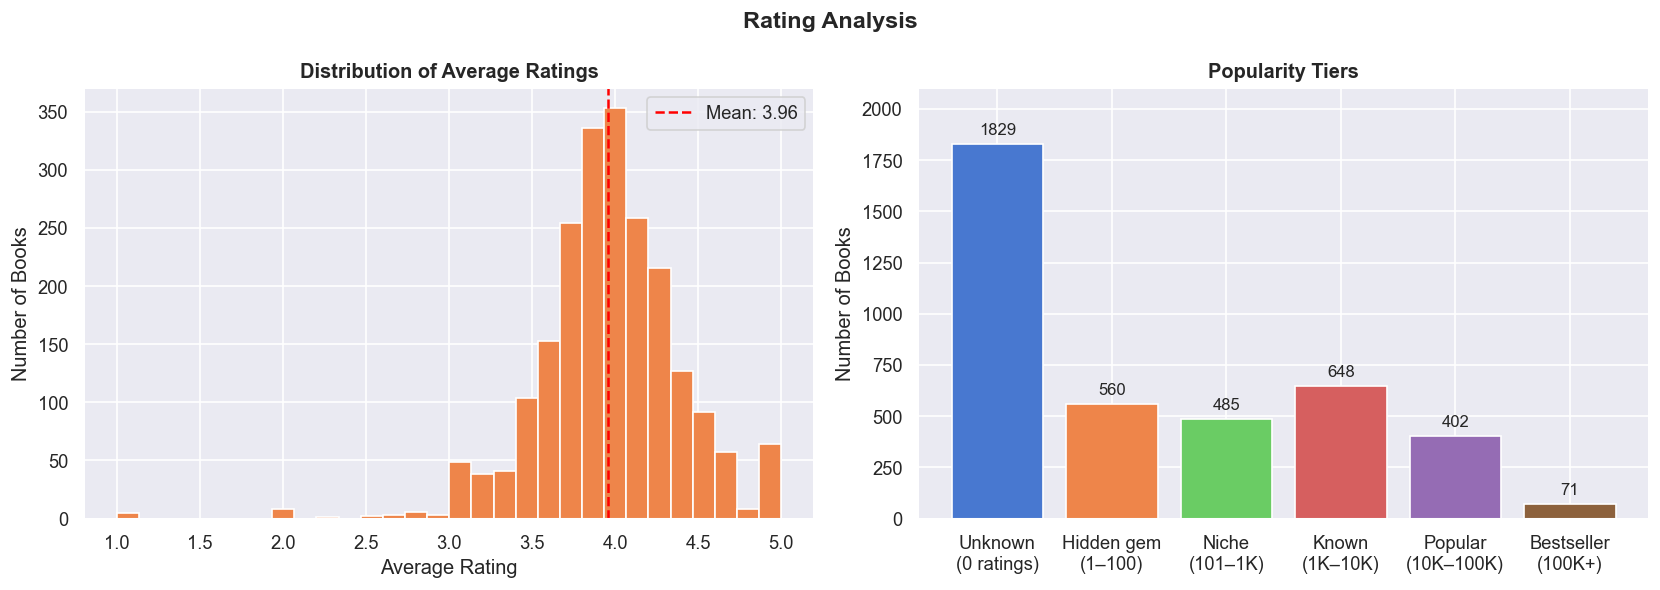

In [4]:
# ── Chart 3 — Fixed right panel: popularity tiers ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram of avg ratings (same as before) ───────────────────────
rated = df[df["avg_rating"] > 0].copy()
ax1.hist(rated["avg_rating"], bins=30,
         color=sns.color_palette("muted")[1], edgecolor="white")
ax1.set_xlabel("Average Rating")
ax1.set_ylabel("Number of Books")
ax1.set_title("Distribution of Average Ratings", fontsize=12, fontweight="bold")
ax1.axvline(rated["avg_rating"].mean(), color="red", linestyle="--",
            label=f"Mean: {rated['avg_rating'].mean():.2f}")
ax1.legend()

# ── Right: popularity tiers as bar chart ──────────────────────────────────
has_ratings = df[df["num_ratings"] > 0].copy()

tiers = {
    "Unknown\n(0 ratings)":      (df["num_ratings"] == 0).sum(),
    "Hidden gem\n(1–100)":       ((has_ratings["num_ratings"] >= 1)   & (has_ratings["num_ratings"] <= 100)).sum(),
    "Niche\n(101–1K)":           ((has_ratings["num_ratings"] > 100)  & (has_ratings["num_ratings"] <= 1000)).sum(),
    "Known\n(1K–10K)":           ((has_ratings["num_ratings"] > 1000) & (has_ratings["num_ratings"] <= 10000)).sum(),
    "Popular\n(10K–100K)":       ((has_ratings["num_ratings"] > 10000) & (has_ratings["num_ratings"] <= 100000)).sum(),
    "Bestseller\n(100K+)":       (has_ratings["num_ratings"] > 100000).sum(),
}

colors = sns.color_palette("muted", len(tiers))
bars = ax2.bar(tiers.keys(), tiers.values(), color=colors, edgecolor="white")
ax2.bar_label(bars, padding=4, fontsize=10)
ax2.set_ylabel("Number of Books")
ax2.set_title("Popularity Tiers", fontsize=12, fontweight="bold")
ax2.set_ylim(0, max(tiers.values()) * 1.15)

plt.suptitle("Rating Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "03_ratings.png", bbox_inches="tight")
plt.show()

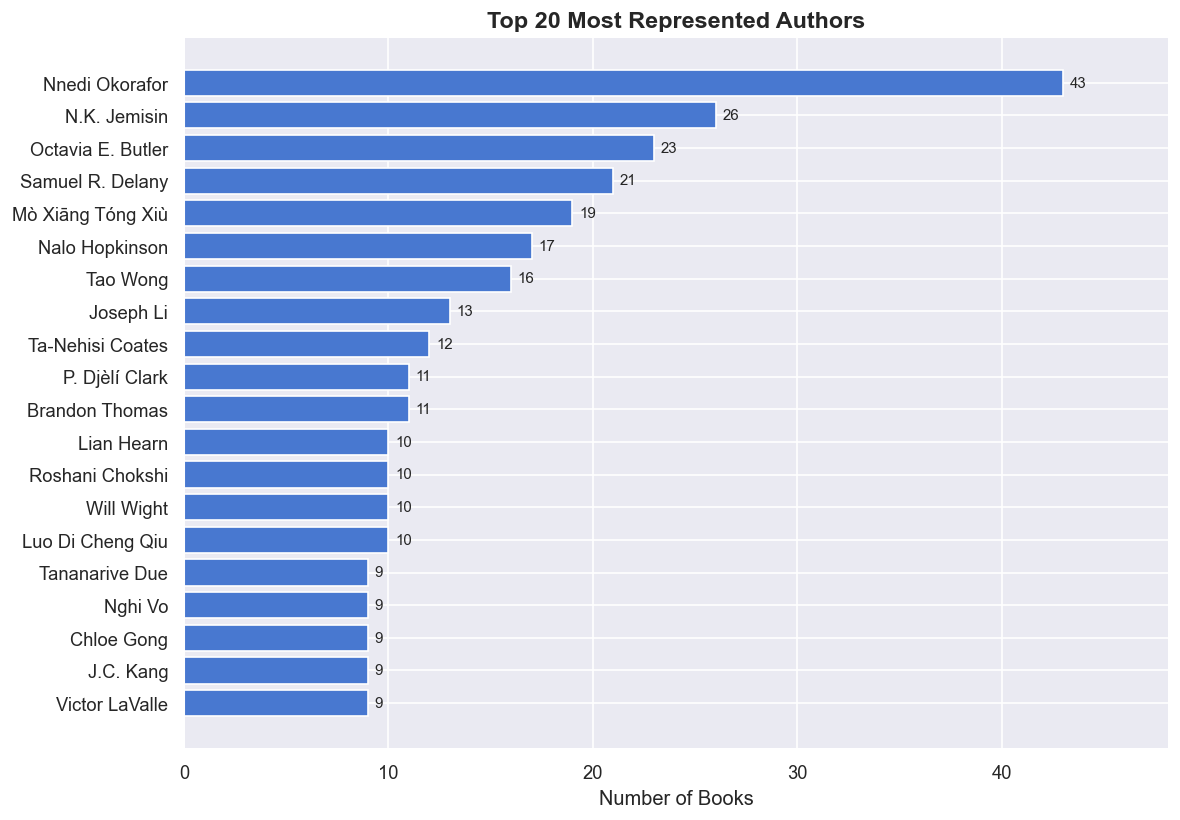

✅ Chart 4 saved


In [5]:
# ── Chart 4 — Top 20 most represented authors ───────────────────────────────
top_authors = df["author"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_authors.index[::-1], top_authors.values[::-1],
               color=sns.color_palette("muted")[0], edgecolor="white")
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("Number of Books")
ax.set_title("Top 20 Most Represented Authors", fontsize=14, fontweight="bold")
ax.set_xlim(0, top_authors.max() * 1.12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "04_top_authors.png")
plt.show()
print("✅ Chart 4 saved")

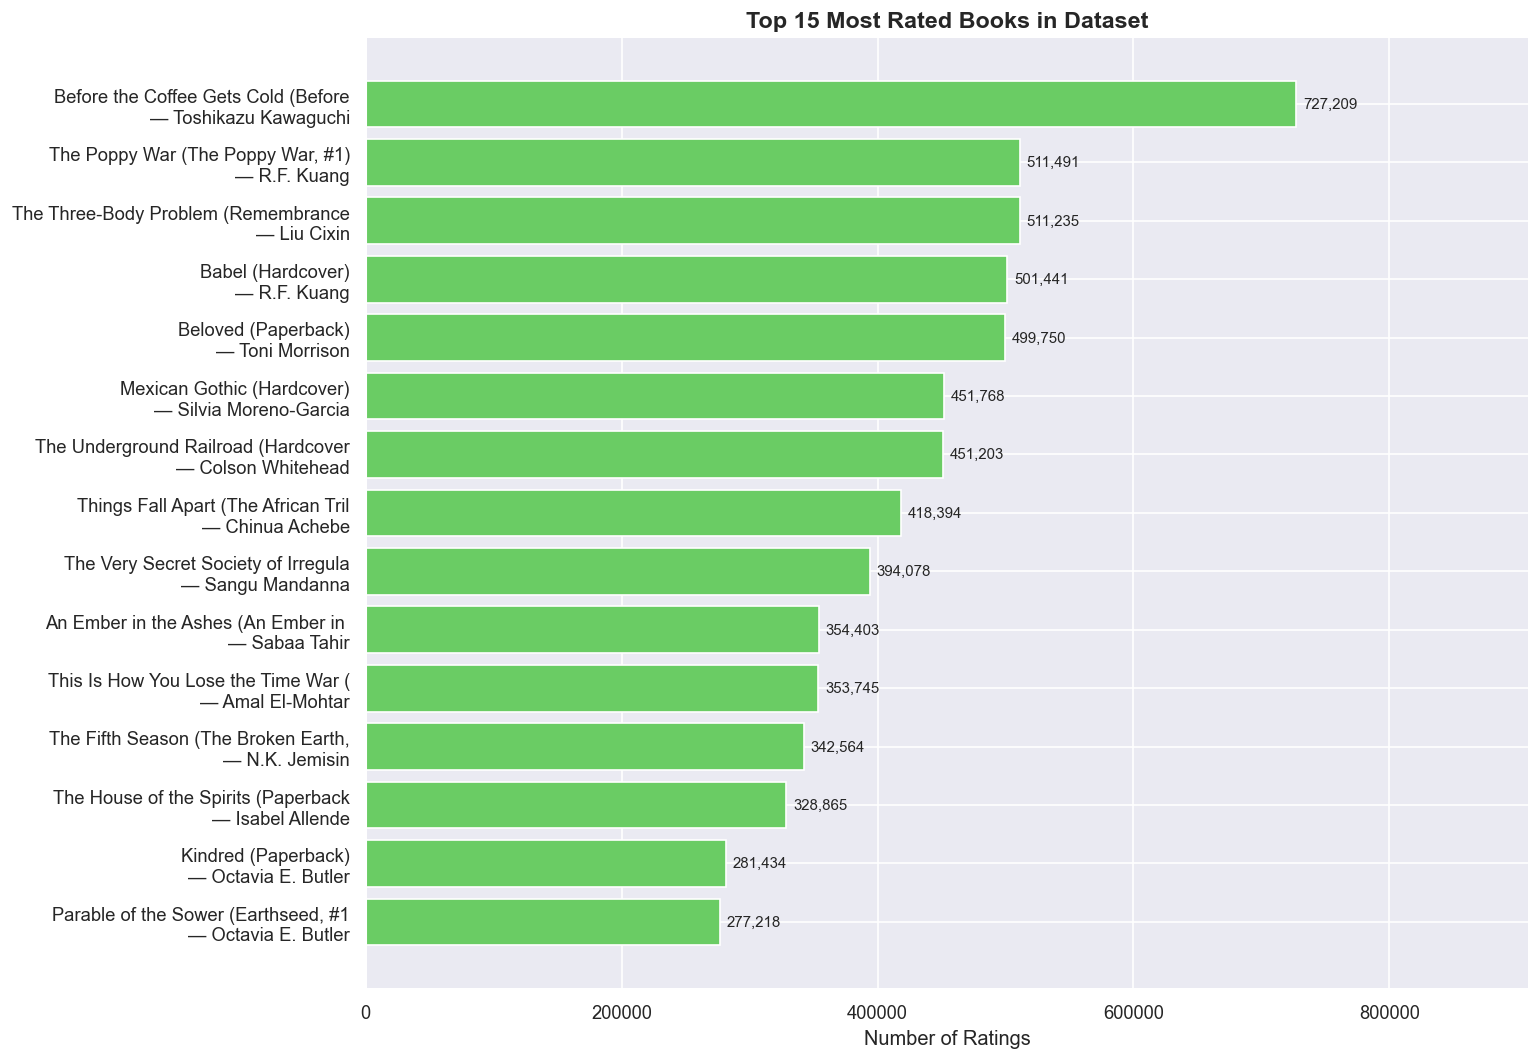

Empty DataFrame
Columns: [title, author, source_tag]
Index: []
Empty DataFrame
Columns: [title, author, source_tag]
Index: []


In [6]:
# ── Chart 5 — Fixed author names ───────────────────────────────────────────
top_rated = df[df["num_ratings"] > 0].nlargest(15, "num_ratings")
labels    = top_rated["title"].str[:35] + "\n— " + top_rated["author"]

fig, ax = plt.subplots(figsize=(13, 9))
bars = ax.barh(labels.values[::-1], top_rated["num_ratings"].values[::-1],
               color=sns.color_palette("muted")[2], edgecolor="white")
ax.bar_label(bars, labels=[f"{v:,}" for v in top_rated["num_ratings"].values[::-1]],
             padding=4, fontsize=9)
ax.set_xlabel("Number of Ratings")
ax.set_title("Top 15 Most Rated Books in Dataset", fontsize=14, fontweight="bold")
ax.set_xlim(0, top_rated["num_ratings"].max() * 1.25)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "05_most_rated.png")
plt.show()

# Check Snow Crash and When the Moon Hatched
for t in ["Snow Crash", "When the Moon Hatched"]:
    found = df[df["title"].str.contains(t, case=False, na=False)][["title","author","source_tag"]]
    print(found.to_string())

In [8]:
print(f"Final dataset: {len(df):,} books")

Final dataset: 3,995 books


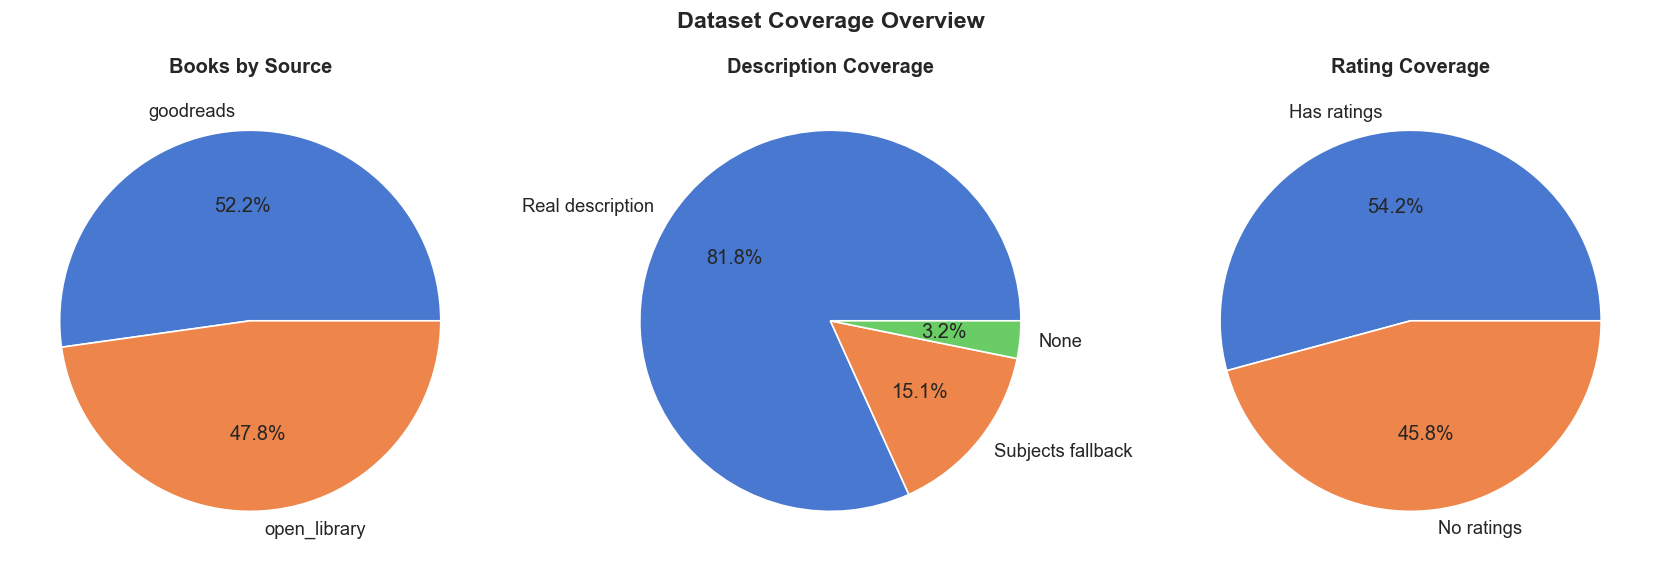

✅ Chart 6 saved


In [9]:
# ── Chart 6 — Coverage heatmap ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Panel 1: Source breakdown ──────────────────────────────────────────────
source_counts = df["source"].value_counts()
axes[0].pie(source_counts.values, labels=source_counts.index, 
            autopct='%1.1f%%', colors=sns.color_palette("muted", 2))
axes[0].set_title("Books by Source", fontweight="bold")

# ── Panel 2: Description coverage ─────────────────────────────────────────
has_real_desc = df["description"].apply(
    lambda x: bool(str(x).strip()) and 
    str(x).strip() != "nan" and 
    "A work of fantasy fiction involving" not in str(x)
).sum()
has_fallback = df["description"].apply(
    lambda x: "A work of fantasy fiction involving" in str(x)
).sum()
has_none = len(df) - has_real_desc - has_fallback

axes[1].pie(
    [has_real_desc, has_fallback, has_none],
    labels=["Real description", "Subjects fallback", "None"],
    autopct='%1.1f%%',
    colors=sns.color_palette("muted", 3)
)
axes[1].set_title("Description Coverage", fontweight="bold")

# ── Panel 3: Rating coverage ───────────────────────────────────────────────
has_rating  = (df["num_ratings"] > 0).sum()
no_rating   = (df["num_ratings"] == 0).sum()
axes[2].pie(
    [has_rating, no_rating],
    labels=["Has ratings", "No ratings"],
    autopct='%1.1f%%',
    colors=sns.color_palette("muted", 2)
)
axes[2].set_title("Rating Coverage", fontweight="bold")

plt.suptitle("Dataset Coverage Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "06_coverage.png")
plt.show()
print("✅ Chart 6 saved")

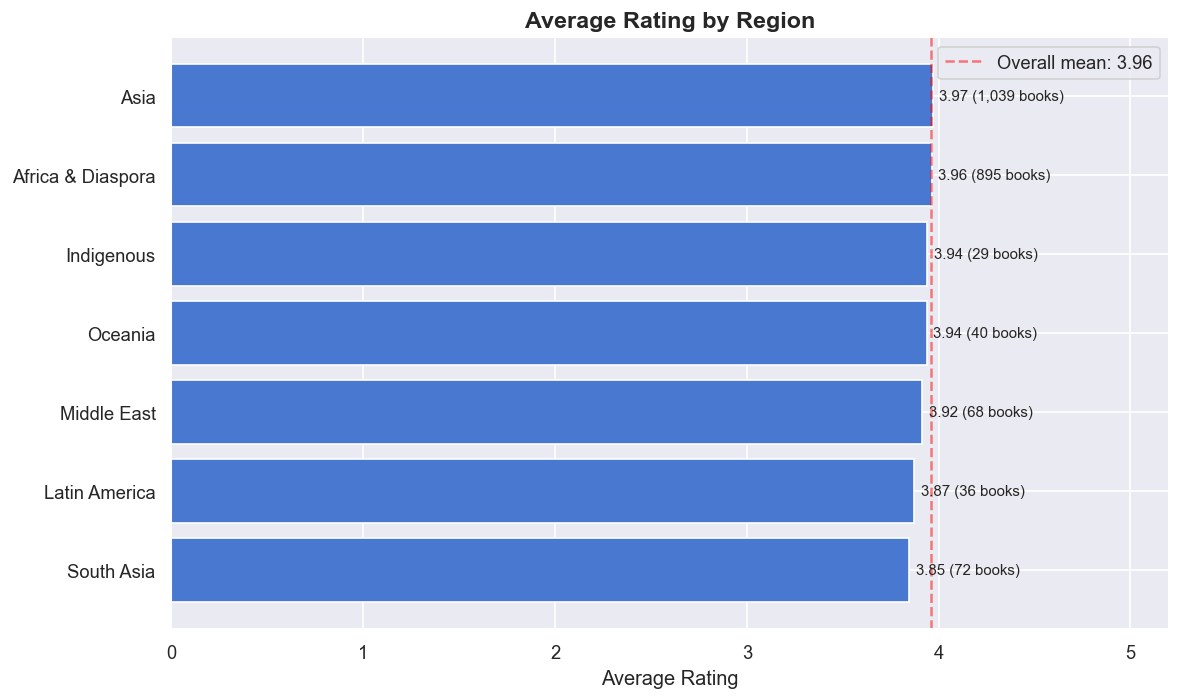

✅ Chart 7 saved — NB04 complete! 🎉


In [11]:
# ── Chart 7 — Fixed: same color ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(region_stats.index, region_stats["avg_rating"],
               color=sns.color_palette("muted")[0], edgecolor="white")
ax.bar_label(bars, labels=[f"{v:.2f} ({region_stats['count'][i]:,} books)" 
                            for i, v in zip(region_stats.index, region_stats["avg_rating"])],
             padding=4, fontsize=9)
ax.set_xlabel("Average Rating")
ax.set_title("Average Rating by Region", fontsize=14, fontweight="bold")
ax.set_xlim(0, 5.2)
ax.axvline(x=rated_df["avg_rating"].mean(), color="red", linestyle="--", 
           alpha=0.5, label=f"Overall mean: {rated_df['avg_rating'].mean():.2f}")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "07_rating_by_region.png")
plt.show()
print("✅ Chart 7 saved — NB04 complete! 🎉")

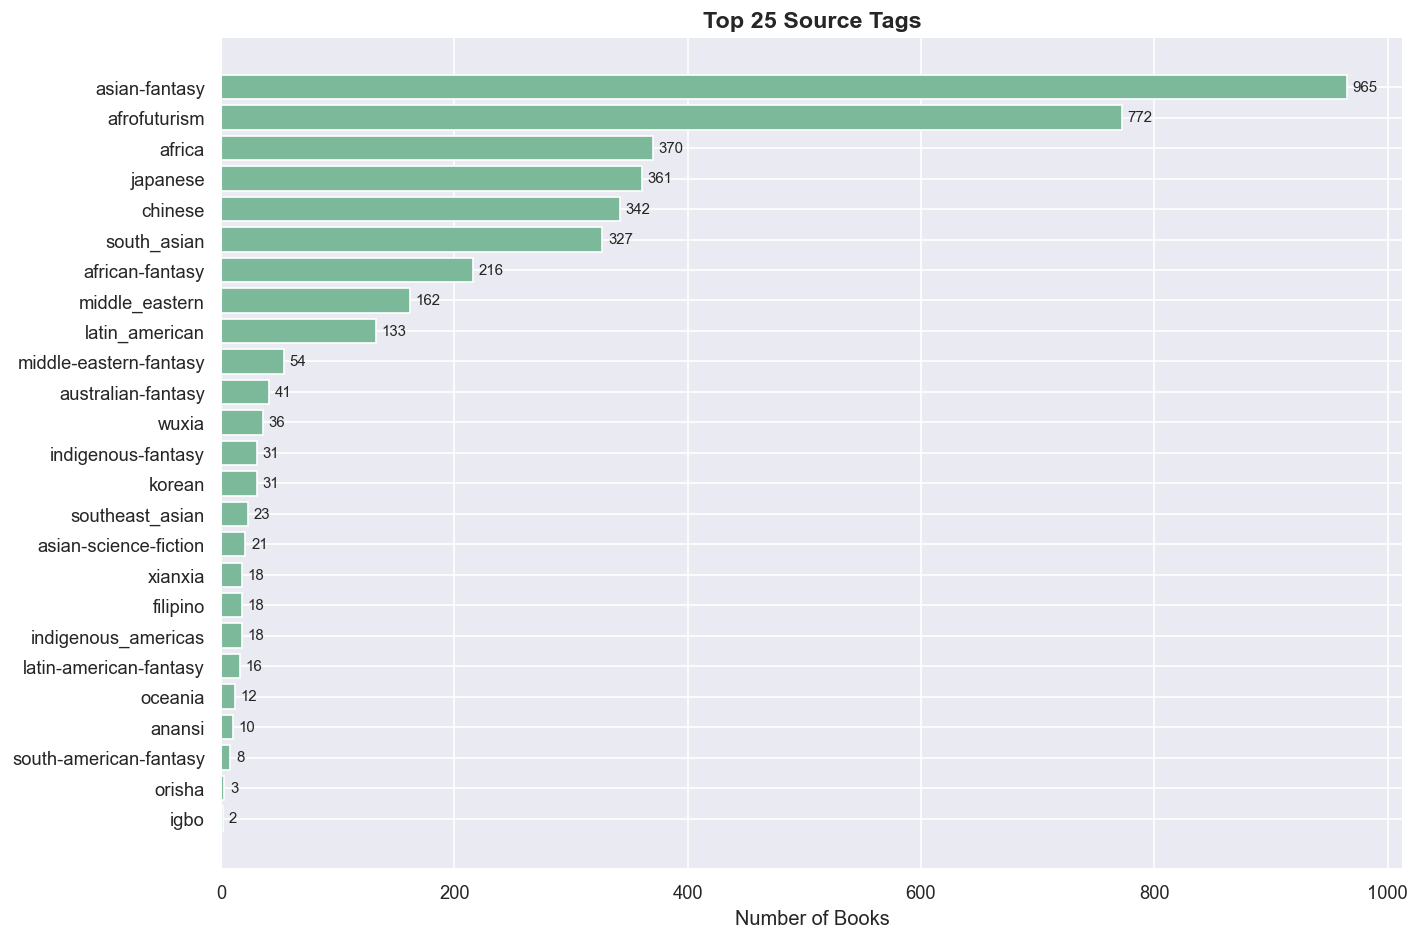

✅ Chart 8 saved


In [12]:
# ── Chart 8 — Top 25 source tags ───────────────────────────────────────────
tag_counts = df["source_tag"].value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(tag_counts.index[::-1], tag_counts.values[::-1], color="#7CB99A")
ax.set_title("Top 25 Source Tags", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Books")

for bar, val in zip(bars, tag_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "08_top_tags.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 8 saved")